#### 1. Data import and device

In [1]:
from IPython.display import display
from PIL import Image
import os
import torch
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from pathlib import Path
from collections import Counter
import pandas as pd
import plotly.express as px
import seaborn as sns

In [2]:
# --- config ---
ROOT = Path().resolve()
DATA_DIR = os.path.join(ROOT, "data", "archive", "train")
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 4
PIN = torch.cuda.is_available()
device = torch.device("cuda" if PIN else "cpu")
torch.multiprocessing.set_sharing_strategy('file_system')

# 设置normalize参数
IMAGENET_MEAN = (0.5, 0.5, 0.5)
IMAGENET_STD = (0.5, 0.5, 0.5)

#对训练图片进行各种操作和加强,包括颜色增强,翻转,旋转
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.ColorJitter(0.1, 0.1, 0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

#对验证集做部分操作
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def get_loaders(
        data_dir: str = DATA_DIR,
        batch_size: int = BATCH_SIZE,
        val_split: float = VAL_SPLIT,
        num_workers: int = NUM_WORKERS,
        pin_memory: bool = PIN,
):
    full = torchvision.datasets.ImageFolder(root=data_dir, transform=train_tf)
    n = len(full)
    n_val = int(n * val_split)
    n_train = n - n_val

    train_set, val_set = random_split(full, [n_train, n_val])

    # clean tf for val
    val_set.dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=val_tf)

    class_to_idx = full.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=False
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=False
    )
    return train_loader, val_loader, idx_to_class

train_loader, val_loader, idx_to_class = get_loaders()

xb, yb = next(iter(train_loader))

#### 2.Data visualization

show image amount, show class amount,and batch size

In [8]:
# ===== Dataset Overview =====
import matplotlib.pyplot as plt

dataset = torchvision.datasets.ImageFolder(root=DATA_DIR)
class_counts = Counter(dataset.targets)

class_table = pd.DataFrame(
    {
        "Class Index": list(range(len(dataset.classes))),
        "Class Name": dataset.classes,
        "Image Count": [class_counts[i] for i in range(len(dataset.classes))],
    }
)

overview = pd.DataFrame(
    {
        "Metric": [
            "Total number of images",
            "Number of classes",
            "Training samples",
            "Validation samples",
            "Train batch size",
            "Validation batch size",
            "Image size",
        ],
        "Value": [
            len(dataset),
            len(dataset.classes),
            len(train_loader.dataset),
            len(val_loader.dataset),
            train_loader.batch_size,
            val_loader.batch_size,
            f"{IMG_SIZE}x{IMG_SIZE}",
        ],
    }
)

display(overview.style.hide(axis="index"))

Metric,Value
Total number of images,15557
Number of classes,23
Training samples,12446
Validation samples,3111
Train batch size,32
Validation batch size,64
Image size,224x224


Display the first 10 images from the dataset.

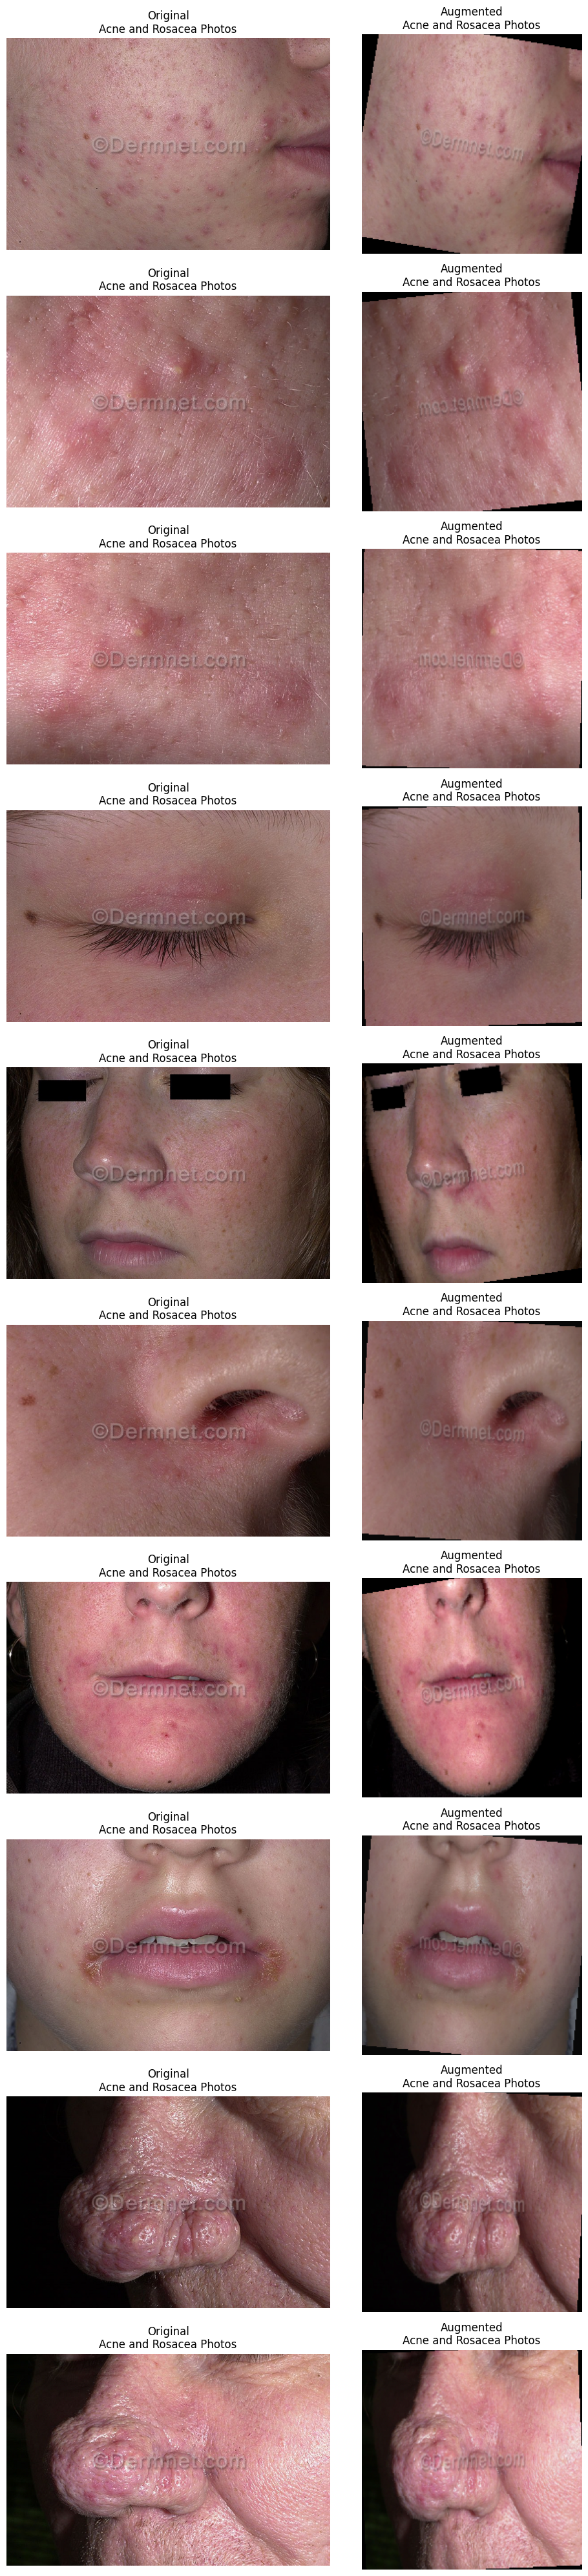

In [6]:
# Compare original images with augmented images from train_tf
import matplotlib.pyplot as plt

def denormalize_image(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)
    image_tensor = image_tensor.detach().cpu() * std_tensor + mean_tensor
    return image_tensor.clamp(0, 1).permute(1, 2, 0).numpy()

num_compare = 10
fig, axes = plt.subplots(num_compare, 2, figsize=(10, 4 * num_compare))

for i in range(num_compare):
    original_img, label = dataset[i]
    augmented_img = train_tf(original_img)

    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Original\n{dataset.classes[label]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(denormalize_image(augmented_img))
    axes[i, 1].set_title(f"Augmented\n{dataset.classes[label]}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Count images per class to check class balance.

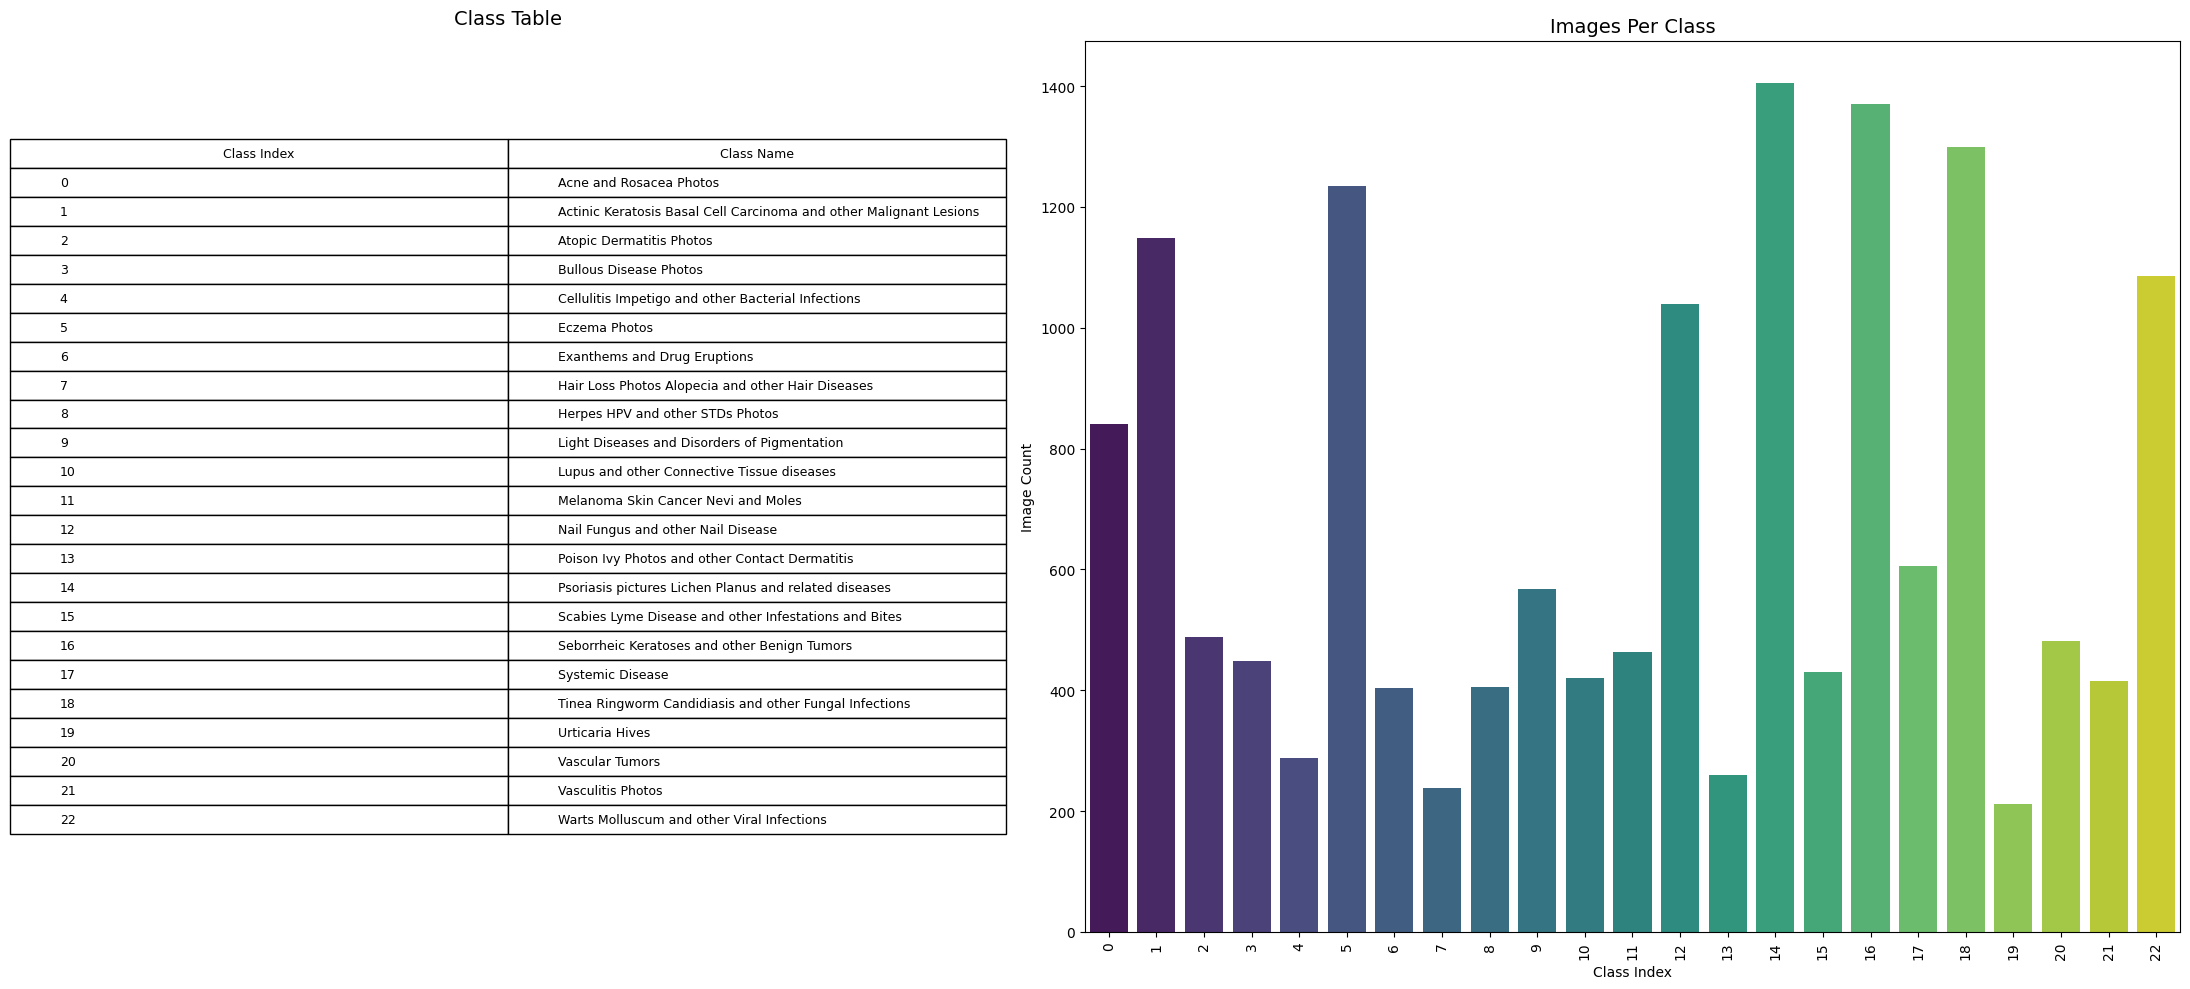

In [12]:
plot_data = class_table.assign(
    **{"Class Index": class_table["Class Index"].astype(str)}
)

fig, (ax_table, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(22, max(10, len(class_table) * 0.4)),
    gridspec_kw={"width_ratios": [2.0, 2.2]},
)

ax_table.axis("off")
table = ax_table.table(
    cellText=class_table[["Class Index", "Class Name"]].values,
    colLabels=["Class Index", "Class Name"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax_table.set_title("Class Table", fontsize=14, pad=12)

sns.barplot(
    data=plot_data,
    x="Class Index",
    y="Image Count",
    hue="Class Index",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax_bar,
  )
ax_bar.set_title("Images Per Class", fontsize=14)
ax_bar.set_xlabel("Class Index")
ax_bar.set_ylabel("Image Count")
ax_bar.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

#### 3. Data cleaning

In [ ]:
### 3. Data cleaning (Optimized with Parallel Processing)


#### 4. Model and comparison model

Our own 20-layer CNN Model

#### 5. Model training

#### 6. Model performance comparison & CV